# Projeto FIAP Fase 4

# Teste de Treinamento

In [98]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

In [99]:
conn = sqlite3.connect("./src/database/bronze.db")

In [100]:
df = pd.read_sql("SELECT * FROM stocks_raw", conn)

df["Date"] = pd.to_datetime(df["Date"])

df


,Date,Ticker,Close,High,Low,Open,Volume
0,2002-01-02,AAPL,0.349069,0.349069,0.328994,0.330342,529496800.0
1,2002-01-02,AMZN,0.548000,0.550000,0.524000,0.546500,130392000.0
2,2002-01-02,MSFT,20.429262,20.450593,19.963022,20.310417,48124000.0
3,2002-01-03,AAPL,0.353264,0.355811,0.341129,0.344574,612007200.0
4,2002-01-03,AMZN,0.595000,0.597000,0.552500,0.556500,217514000.0
...,...,...,...,...,...,...,...
27279,2026-04-17,AAPL,270.230011,272.299988,266.720001,266.959991,61436200.0
27280,2026-04-17,AMZN,250.559998,256.179993,250.110001,254.990005,52029300.0
27281,2026-04-17,GOOGL,341.679993,342.320007,336.239990,337.649994,25581900.0
27282,2026-04-17,META,688.549988,691.520020,675.130005,678.599976,16283500.0


In [101]:
list_tickers = list(df["Ticker"].unique())
list_tickers

['AAPL', 'AMZN', 'MSFT', 'GOOGL', 'META']

## Treinamento de modelo

In [56]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.tensorflow

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping


In [57]:

# =========================
# 1. FILTRO E FEATURES
# =========================

df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Date")

# 🔥 Feature Engineering (diferencial)
df_aapl["MA_10"] = df_aapl["Close"].rolling(10).mean()
df_aapl["MA_50"] = df_aapl["Close"].rolling(50).mean()
df_aapl["VOLATILITY"] = df_aapl["Close"].rolling(10).std()

df_aapl = df_aapl.dropna()


In [58]:

# =========================
# 2. SELEÇÃO DE FEATURES
# =========================

features = ["Open", "High", "Low", "Close", "Volume", "MA_10", "MA_50", "VOLATILITY"]
data = df_aapl[features].values


In [59]:

# =========================
# 3. NORMALIZAÇÃO
# =========================

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [60]:

# =========================
# 4. SEQUÊNCIAS
# =========================

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # ✅ Close correto
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size=60)


In [61]:

# =========================
# 5. SPLIT
# =========================

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)


X_train: (4802, 60, 8)


In [62]:

# =========================
# 6. MODELO MELHORADO
# =========================

model = Sequential()

model.add(LSTM(
    32,
    activation='tanh',
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(Dropout(0.2))

model.add(LSTM(32, activation='tanh'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # 🔥 sem sigmoid

model.compile(
    optimizer=SGD(learning_rate=0.005),
    loss='mean_squared_error'
)


/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [63]:

# =========================
# 7. EARLY STOPPING
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [64]:

# =========================
# 8. MLFLOW
# =========================

mlflow.set_experiment("LSTM_STOCK_PREDICTION")

with mlflow.start_run():

    mlflow.log_param("window_size", 60)
    mlflow.log_param("optimizer", "SGD")
    mlflow.log_param("learning_rate", 0.005)
    mlflow.log_param("lstm_units", 32)
    mlflow.log_param("features", features)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,  # 🔥 deixa o early stopping decidir
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    loss = model.evaluate(X_test, y_test)
    mlflow.log_metric("loss", loss)

    mlflow.tensorflow.log_model(model, "model")


Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0151 - val_loss: 0.4236
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0101 - val_loss: 0.3532
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0084 - val_loss: 0.3061
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0068 - val_loss: 0.2634
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0051 - val_loss: 0.2284
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0042 - val_loss: 0.1987
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0033 - val_loss: 0.1755
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0027 - val_loss: 0.1558
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0021 - val_loss: 0.1397
Epoch 10/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0019 - val_loss: 0.1246
Epoch 11/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0014 - val_loss: 0.1143
Epoch 12/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 

2026/04/21 17:31:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:31:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [65]:

# =========================
# 9. PREDIÇÃO
# =========================

predictions = model.predict(X_test)

# reconstruir escala só do Close
close_scaler = MinMaxScaler()
close_scaler.fit(df_aapl[["Close"]])

predictions_real = close_scaler.inverse_transform(predictions.reshape(-1,1))
y_test_real = close_scaler.inverse_transform(y_test.reshape(-1,1))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


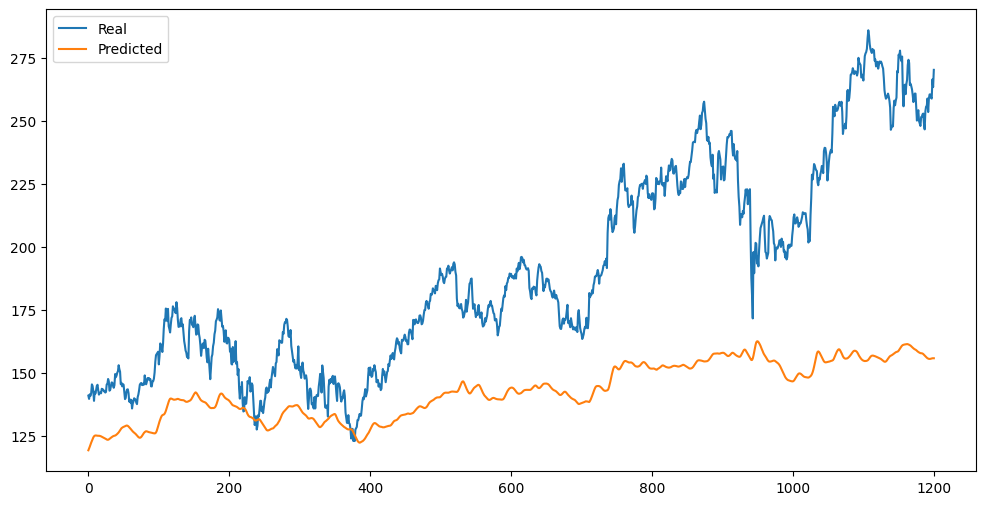

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Real")
plt.plot(predictions_real, label="Predicted")
plt.legend()
plt.show()

# Teste de melhorias

In [102]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.tensorflow

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [103]:

# =========================
# 1. PREPARAÇÃO DOS DADOS
# =========================

df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Date")

# 🔥 Feature Engineering
df_aapl["MA_10"] = df_aapl["Close"].rolling(10).mean()
df_aapl["MA_50"] = df_aapl["Close"].rolling(50).mean()
df_aapl["VOLATILITY"] = df_aapl["Close"].rolling(10).std()
df_aapl["RETURN"] = df_aapl["Close"].pct_change()
df_aapl["MOMENTUM"] = df_aapl["Close"] - df_aapl["Close"].shift(5)

df_aapl = df_aapl.dropna()

features = ["Open", "High", "Low", "Close", "Volume", "MA_10", "MA_50", "VOLATILITY", "RETURN", "MOMENTUM"]
data = df_aapl[features].values


In [104]:

# =========================
# 2. NORMALIZAÇÃO
# =========================

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [105]:

# =========================
# 3. CRIAR SEQUÊNCIAS (CLASSIFICAÇÃO)
# =========================

def create_sequences(data, window_size=60, horizon=5):
    X, y = [], []
    for i in range(window_size, len(data) - horizon):
        X.append(data[i-window_size:i])

        # 🔥 direção em 5 dias
        if data[i + horizon, 3] > data[i, 3]:
            y.append(1)
        else:
            y.append(0)

    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size=60)


In [106]:

# =========================
# 4. SPLIT
# =========================

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)


X_train: (4798, 60, 10)


In [107]:

# =========================
# 5. MODELO LSTM
# =========================

model = Sequential()

model.add(LSTM(
    32,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # classificação

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [108]:

# =========================
# 6. EARLY STOPPING
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [109]:

# =========================
# 7. MLFLOW
# =========================

mlflow.set_experiment("LSTM_DIRECTION_PREDICTION")

with mlflow.start_run():

    mlflow.log_param("window_size", 60)
    mlflow.log_param("lstm_units", 32)
    mlflow.log_param("optimizer", "SGD")
    mlflow.log_param("learning_rate", 0.005)
    mlflow.log_param("features", features)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test)

    mlflow.log_metric("loss", loss)
    mlflow.log_metric("accuracy", acc)

    mlflow.tensorflow.log_model(model, "model")


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5817 - loss: 0.6811 - val_accuracy: 0.5433 - val_loss: 0.6998
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5834 - loss: 0.6802 - val_accuracy: 0.5433 - val_loss: 0.6976
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6798 - val_accuracy: 0.5433 - val_loss: 0.6912
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5832 - loss: 0.6802 - val_accuracy: 0.5433 - val_loss: 0.6946
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6795 - val_accuracy: 0.5433 - val_loss: 0.7025
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6796 - val_accuracy: 0.5433 - val_loss: 0.6973
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6795 - val_accuracy: 0.5433 - val_loss: 0.6897
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6794 - val_accu

2026/04/21 17:53:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:53:41 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [113]:

# =========================
# 8. PREVISÃO
# =========================

pred_probs = model.predict(X_test)
threshold = 0.55

preds = []

for p in pred_probs:
    if p > threshold:
        preds.append(1)  # compra
    elif p < (1 - threshold):
        preds.append(0)  # vende
    else:
        preds.append(-1)  # NÃO FAZ NADA
        


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [115]:

# =========================
# 9. MÉTRICA PRINCIPAL
# =========================

accuracy = accuracy_score(y_test, preds)
print("Directional Accuracy:", accuracy)


Directional Accuracy: 0.32416666666666666


In [116]:

# =========================
# 10. SIMULAÇÃO DE LUCRO
# =========================

prices = df_aapl["Close"].values[-len(preds):]

profit = 0

for i in range(1, len(preds)):
    if preds[i] == 1:
        profit += (prices[i] - prices[i-1])
    elif preds[i] == 0:
        profit += (prices[i-1] - prices[i])  # venda (short)

print("Simulated Profit:", profit)

Simulated Profit: 122.5233154296875
